In [2]:
library(Seurat)
library(dplyr)
library(ggplot2)
library(patchwork)
library(cowplot)
library(Matrix)
library(Seurat)
library(ggplot2)
library(dplyr)
library(stringr)
library(msigdbr)
library(tidyverse)
library(ggpubr)
library(rstatix)
library(ggprism)
library(reshape2)
library(Seurat)
library(ggplot2)
library(cowplot)
library(tidyverse)
library(dplyr)
library(Seurat)
library(ggplot2)
library(patchwork)
library(ggsci)
library(circlize)
library(RColorBrewer)
library(ComplexHeatmap)
library(scCustomize)
library(ggplot2)
library(ggforce)
library(dplyr)
library(ggrepel)
library(patchwork)
library(ggpubr)
library(export)
library(org.Mm.eg.db)#
library("clusterProfiler")
library(biomaRt)
library(tidyverse)
library(limma)
library(IOBR)
library(fgsea)
library(Seurat)
library(Seurat)
library(ggplot2)
library(dplyr)
library(stringr)
library(DESeq2)
library("FactoMineR")
library(ggplot2)
library(vegan)
library(ape)
library(phyloseq)
library(ggalt)
library(microeco)
#library(jsd)
library("factoextra")
library(Seurat)
library(stringr)
library(ggplot2)
library(pheatmap)
library(dplyr)
library("spatstat.geom")
library(Seurat)
library(Rcpp)
library(harmony)
library(stringr)
library(dplyr)
library(patchwork)
library(ggplot2)
library(ggpubr)
library(reshape2)
library(scales)
library(ggsignif)
library(corrplot)
library(edgeR)
library(ggplot2)
library(FactoMineR)
library(factoextra)  
library(corrplot)   
library(pheatmap)
library(tidyverse)
library(clusterProfiler)
library(org.Hs.eg.db)  
library(GSEABase)    
library(dplyr)
library(Seurat)
library(patchwork)
library(ggplot2)
library(cowplot)
library(monocle)
library(tidyverse)
library(reshape2)
library(ggplot2)
library(ggpubr)
library(GO.db)
library(org.Hs.eg.db)
library(clusterProfiler)
library(enrichplot)
library(ggplot2)
library(ggnewscale)
library(org.Mm.eg.db)
library(dplyr)
library(stringr)
library(ComplexUpset)
options(warn=-1)####忽略警告

In [3]:
sp <- readRDS("./merge_red.RDS")

In [4]:
setwd("./08sup5/")

In [49]:
sp1 <- subset(sp,subset=area%in%c("Cornea&conj"))

In [28]:
m <- as.matrix(table(as.character(sp1$sample), sp1$celltype))
m
plot_df <- as.data.frame(m)
head(plot_df)

       
         CEC Conj  CSK  LSC Microglia Proliferation cell
  RIR1   542  428  119  158       194                 32
  RIR2   545  428   95  270       375                 50
  RIR3   502  542  303  635       436                 47
  RIR4   470  389  779  706       137                  8
  RIR5   307  523   21  717      1184                110
  RIR6   547  334  542  662       330                 32
  Sham1  401  208  428   61        40                  3
  Sham2  418  201  489  123        71                  7
  Sham3  489  376  625  771        88                 20
  Sham4  120  470   61  667       100                  6
  Sham5  618  459  623  623        71                 25

,Var1,Var2,Freq
,<fct>,<fct>,<int>
1,RIR1,CEC,542
2,RIR2,CEC,545
3,RIR3,CEC,502
4,RIR4,CEC,470
5,RIR5,CEC,307
6,RIR6,CEC,547


In [262]:
cell_order <- c(
  # 基质细胞
  'Fibroblast', 'VEC', 'CEC', 'LEC', 'SMC', 'Muscle', 'RPE', 
  'Conj', 'LSC', 'CSK', 'PCE', 'NPCE', 'Proliferation cell',
  
  # 神经细胞
  'Rod', 'Cone', 'RGC', 'AC', 'HC', 'CBC', 'RBC','Macroglia', 
   'Oligodendrocyte', 'Schwann cell', 'Melanocyte',
  # 免疫细胞
  'Microglia','Myeloid', 'Neutrophil', 'DC', 'Lymphocyte'
)
cols <- c('Rod'="#77AC30",'Melanocyte'="#34183E",'VEC'="#238b45",'Microglia'="#ce1256",
          'Macroglia'="#DD7C4F",'Schwann cell'="#925EB0",'Oligodendrocyte'="#682487",
          'Myeloid'="#DCA7EB",'Neutrophil'="#B55384",'NPCE'="#B7F5DE",'DC'="#df65b0",
          'Lymphocyte'="#D5AABE",'Fibroblast'="#8b4a4b",'AC'="#B8DBB3",
          'CEC'="#40B7AD",'RPE'="#58B6E9",'PCE'="#D6E2E2",'Cone'="#C8E63C",
          'CBC'="#FCB6A5",'RBC'="#08306B",
          'RGC'="#FAA419",
          'SMC'="#1f78b4",'Proliferation cell'="#A1CFFA",'HC'="#004600",
          'Conj'="#6C61AF",'CSK'="#D6EFF4",
          'LEC'="#72B063",'Muscle'="#EAE936",'LSC'="#8CBF87")

In [9]:
sa <- c("Sham1","Sham2","Sham3","Sham4","Sham5","RIR1","RIR2","RIR3","RIR4","RIR5","RIR6")

In [10]:
colnames(plot_df) <- c('type','celltype','sum')
head(plot_df)

,type,celltype,sum
,<fct>,<fct>,<int>
1,RIR1,CEC,542
2,RIR2,CEC,545
3,RIR3,CEC,502
4,RIR4,CEC,470
5,RIR5,CEC,307
6,RIR6,CEC,547


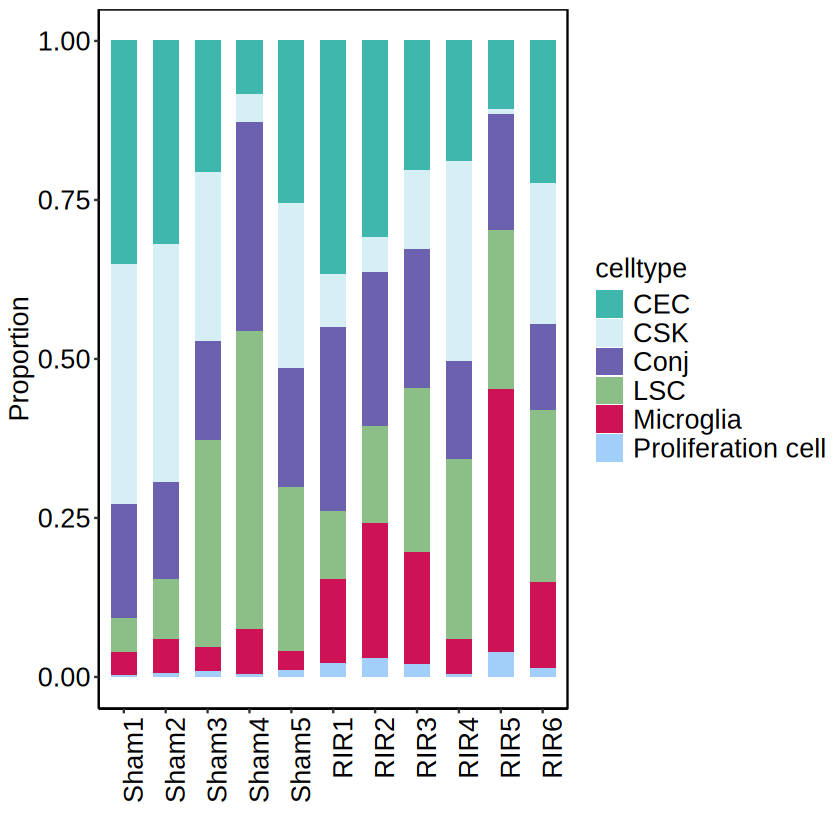

In [29]:
colnames(plot_df) <- c('type','celltype','sum')
    plot_df$celltype <- factor(plot_df$celltype,levels = c('CEC','CSK','Conj','LSC','Microglia','Proliferation cell'))
  plot_df$type <- factor(plot_df$type,levels = sa)
    p1 <- ggplot(plot_df, mapping = aes(type,sum,fill=celltype))+geom_bar(stat='identity',position="fill",width = 0.6)+
    labs(x = "",y = 'Proportion') +theme(axis.title =element_text(size = 16),axis.text =element_text(size = 14, color = 'black'))+
    theme(
        plot.title= element_text(color = 'black', size   = 20, hjust = 0.5),
        plot.subtitle = element_text(color = 'black', size   = 16,hjust = 0.5),
        plot.caption  = element_text(color = 'black', size   = 16,face = 'italic', hjust = 1),
        axis.text.x   = element_text(color = 'black', size = 16, angle = 90,hjust = 1),
        axis.text.y   = element_text(color = 'black', size = 16, angle = 0),
        axis.title.x  = element_text(color = 'black', size = 16, angle = 0),
        axis.title.y  = element_text(color = 'black', size = 16, angle = 90),
        legend.title  = element_text(color = 'black', size  = 16),
        legend.text   = element_text(color = 'black', size   = 16),
        axis.line.y = element_line(color = 'black', linetype = 'solid'),
        axis.line.x = element_line (color = 'black',linetype = 'solid'), 
        panel.background=element_rect(fill="white"))+scale_fill_manual(values =cols)+
    theme(panel.border = element_rect(fill = NA,color = "black",size=0.5,linetype = "solid"))
    print(p1)
ggsave("Cornea&conj_stat.pdf",p1,width = 7,height = 6)

In [16]:
###deg
Idents(sp1) <- as.factor(sp1@meta.data$group)
sp1 <- ScaleData(sp1, features = rownames(sp1))
deg <- FindAllMarkers(sp1,slot="scale.data")
deg1 <- subset(deg,subset = cluster=="RIR")

Centering and scaling data matrix



In [99]:
deg <- FindAllMarkers(sp1,slot="scale.data")

Calculating cluster RIR

Calculating cluster Sham



In [101]:
deg1 <- subset(deg,subset = cluster=="RIR")

In [ ]:
deg

In [103]:
library(Seurat)
library(ggplot2)
library(dplyr)
library(ggplot2)
library(ggridges)
library(RColorBrewer)
library(scales)
library(stringr)
library(ggVolcano)

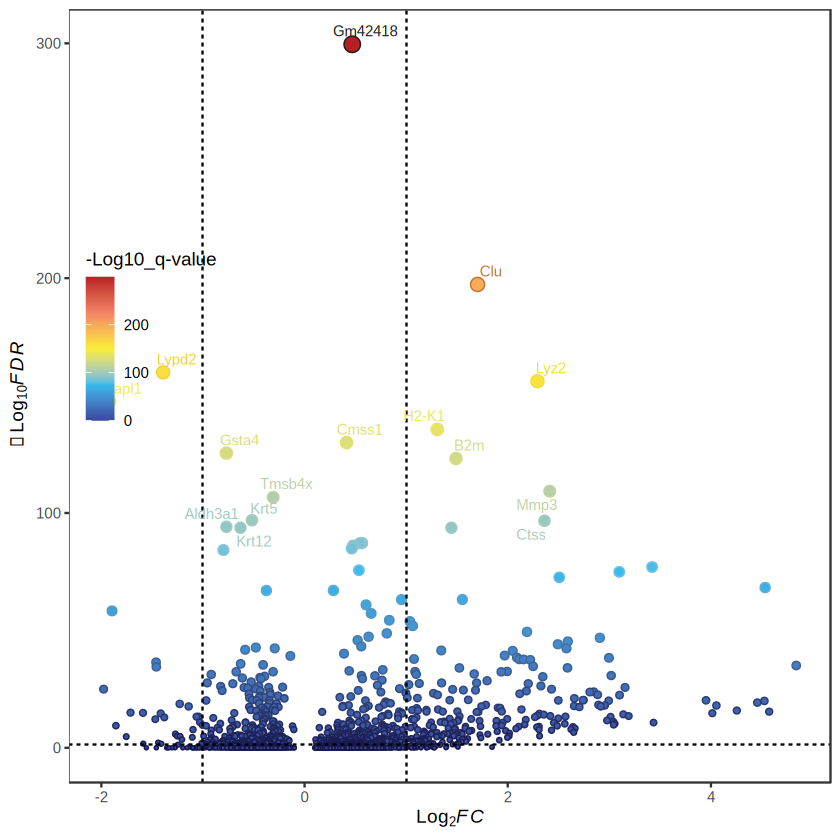

In [179]:
p3 <- gradual_volcano(deg1,
                      x = "avg_log2FC",
                      y = "p_val_adj",
                      label = "gene",
                      label_number = 15,
                      #fills = brewer.pal(5, "RdYlBu"),colors = brewer.pal(8, "RdYlBu"),
                      output = FALSE)
p3

In [180]:
pdf("Cornea_deg.pdf",width=6,height=6)
print(p3)
dev.off()

pdf 
  2

In [196]:
gene <- deg1[which(abs(deg1$avg_log2FC)>1&deg1$p_val_adj< 0.05),]$gene

In [197]:
length(gene)

[1] 258

In [200]:
gene <- deg1[which(abs(deg1$avg_log2FC)>1.5&deg1$p_val_adj< 0.05&deg1$`pct.1`>0.02),]$gene
length(gene)
gene

[1] 69

[1] "Clu"       "Lyz2"      "Dapl1"     "Mmp3"      "Ctss"      "Saa3"     
 [7] "Krt16"     "Chil1"     "Il1b"      "Serpina3n" "Fam25c"    "Cemip"    
[13] "Ms4a6c"    "Ccl6"      "Fcer1g"    "Cybb"      "Mpeg1"     "Laptm5"   
[19] "H2-Ab1"    "Ccr2"      "Cd52"      "Lcp1"      "Spp1"      "Mmp12"    
[25] "Csf1r"     "Coro1a"    "Steap4"    "Lox"       "Fcgr3"     "Cebpb"    
[31] "S100a8"    "Zbp1"      "C1qb"      "Cebpd"     "Cfb"       "Ptprc"    
[37] "Ms4a6d"    "Srgn"      "H2-Aa"     "H2-Eb1"    "Tyrobp"    "Socs3"    
[43] "Csf3r"     "Fxyd5"     "Ccl2"      "Pirb"      "Hp"        "Ifit1"    
[49] "Pf4"       "Adgre1"    "Ms4a7"     "Fcgr2b"    "Cyba"      "Cd93"     
[55] "Cxcl5"     "Iigp1"     "Mrc1"      "Slfn5"     "Fyb"       "Pmel"     
[61] "Myoc"      "Cfp"       "Rtp4"      "Aif1"      "Bcl3"      "C3ar1"    
[67] "Il4ra"     "Tnc"       "Arhgap45"

In [122]:
sp1@meta.data$sample <- factor(sp1@meta.data$sample,levels = c("Sham1","Sham2","Sham3","Sham4","Sham5","RIR1","RIR2","RIR3","RIR4","RIR5","RIR6"))

In [123]:
####heatmap plot 
mean_gene_exp<-AverageExpression(sp1,features=gene,group.by='sample',slot='scale.data')%>%data.frame()%>%as.matrix()
unique(sp1@meta.data$sample)
colnames(mean_gene_exp)

[1] Sham1 Sham2 RIR2  RIR1  RIR5  Sham5 RIR6  RIR3  RIR4  Sham4 Sham3
Levels: Sham1 Sham2 Sham3 Sham4 Sham5 RIR1 RIR2 RIR3 RIR4 RIR5 RIR6

[1] "RNA.Sham1" "RNA.Sham2" "RNA.Sham3" "RNA.Sham4" "RNA.Sham5" "RNA.RIR1" 
 [7] "RNA.RIR2"  "RNA.RIR3"  "RNA.RIR4"  "RNA.RIR5"  "RNA.RIR6"

In [124]:
library(circlize)
library(ComplexHeatmap)

In [125]:
colnames(mean_gene_exp) <-  c("Sham1","Sham2","Sham3","Sham4","Sham5","RIR1","RIR2","RIR3","RIR4","RIR5","RIR6")
colnames(mean_gene_exp)

[1] "Sham1" "Sham2" "Sham3" "Sham4" "Sham5" "RIR1"  "RIR2"  "RIR3"  "RIR4" 
[10] "RIR5"  "RIR6"

In [126]:
cols <- c("Sham1"="#5E3C99","Sham2"="#8065AD","Sham3"="#A28FC2","Sham4"="#C3B8D7","Sham5"="#E6E2EC","RIR1"="#DEEDE8","RIR2"="#ADD9CC","RIR3"="#7CC5AF","RIR4"="#4BB193","RIR5"="#1B9E77","RIR5"="#0F7A5C","RIR6"="#238b45")

In [134]:
####bulk ###let doit
n=0
for(i in unique(sp1@meta.data$sample)){
    n=n+1
    pbmc <- subset(sp1,subset=sample==i)
        counts <- data.frame(rowSums(as.matrix(pbmc@assays$RNA$counts)))
        colnames(counts) <- i
        m <- as.data.frame(i)
        colnames(m) <- "names"
        m$sample <- i
        if(n==1){
            counts1 <- counts
            m1 <- m
        }
        else{
            counts1 <- merge(counts1,counts,all=TRUE,by=0)
            rownames(counts1) <- counts1$Row.names
            counts1 <- counts1[,-1]
            m1 <- rbind(m1,m)
        }
    }

In [131]:
i

[1] "Sham2"

In [133]:
subset(sp1,subset=sample==i)

An object of class Seurat 
24382 features across 1309 samples within 1 assay 
Active assay: RNA (24382 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: pca, harmony, umap

In [135]:
m <- as.data.frame(unique(sp1@meta.data$sample))
rownames(m) <- m[,1]
colnames(m) <- "group"
m$group <- substr(m$group,1,3)
m$batch <- c("1","1","1","1","2","2","2","2","2","2","2")
m$group <- str_replace(m$group,"Sha","Sham")
m$sample <- rownames(m)
m

,group,batch,sample
,<chr>,<chr>,<chr>
Sham1,Sham,1,Sham1
Sham2,Sham,1,Sham2
RIR2,RIR,1,RIR2
RIR1,RIR,1,RIR1
RIR5,RIR,2,RIR5
Sham5,Sham,2,Sham5
RIR6,RIR,2,RIR6
RIR3,RIR,2,RIR3
RIR4,RIR,2,RIR4


In [138]:
m1$group <- substr(m1$names,1,3)
m1$group <- str_replace(m1$group,"Sha","Sham")
m1$batch <- "NA"
for(i in unique(m$sample)){
    m1[which(m1$sample==i),]$batch <- m[which(m$sample==i),]$batch
}

In [141]:
library(sva)
library(limma)

In [142]:
exp <- counts1
mm <- m

In [143]:
mm <- m

In [144]:
####batch
mod = model.matrix(~mm$group)
exp2 = ComBat_seq(counts = as.matrix(exp), batch = factor(mm$batch),group = factor(mm$group))
class(exp2)
dat = log2(edgeR::cpm(exp2)+1)

Found 2 batches
Using full model in ComBat-seq.
Adjusting for 1 covariate(s) or covariate level(s)
Estimating dispersions
Fitting the GLM model
Shrinkage off - using GLM estimates for parameters
Adjusting the data


[1] "matrix" "array"

In [146]:
se <- CreateSeuratObject(counts = exp2,meta.data = mm)

In [147]:
se

An object of class Seurat 
24382 features across 11 samples within 1 assay 
Active assay: RNA (24382 features, 0 variable features)
 1 layer present: counts

In [148]:
####limma deg
library(dplyr) # 数据处理
library(data.table) # 数据读取
library(stringr) # 数据处理
library(limma) # limma差异分析
library(edgeR) # edgeR差异分析
library(DESeq2) # DESeq2差异分析 

In [149]:
# 构建线性模型，0代表x线性模型的截距为0
design <- model.matrix(~0+mm$group)  # 生成设计矩阵，又叫分组矩阵，分组依据是factor的level水平
rownames(design) <- colnames(exp2)  # 设计矩阵的行名，与表达矩阵的列名一一对应
colnames(design) <- levels(factor(mm$group))   # 设计矩阵的列名，与生成的分组信息一致
design

,RIR,Sham
Sham1,0,1
Sham2,0,1
RIR2,1,0
RIR1,1,0
RIR5,1,0
Sham5,0,1
RIR6,1,0
RIR3,1,0
RIR4,1,0
Sham4,0,1


In [ ]:
DEG <- DGEList(counts=exp2,group=factor(mm$group))
DEG  
# 归一化基因表达分布
DEG <- calcNormFactors(DEG)
# 计算线性模型的参数
DEG <- estimateGLMCommonDisp(DEG,design)
DEG <- estimateGLMTrendedDisp(DEG, design)
DEG <- estimateGLMTagwiseDisp(DEG, design)
# 拟合线性模型
fit <- glmFit(DEG, design)

In [151]:
DGElist <- DGEList(counts = exp2, group = mm$group)

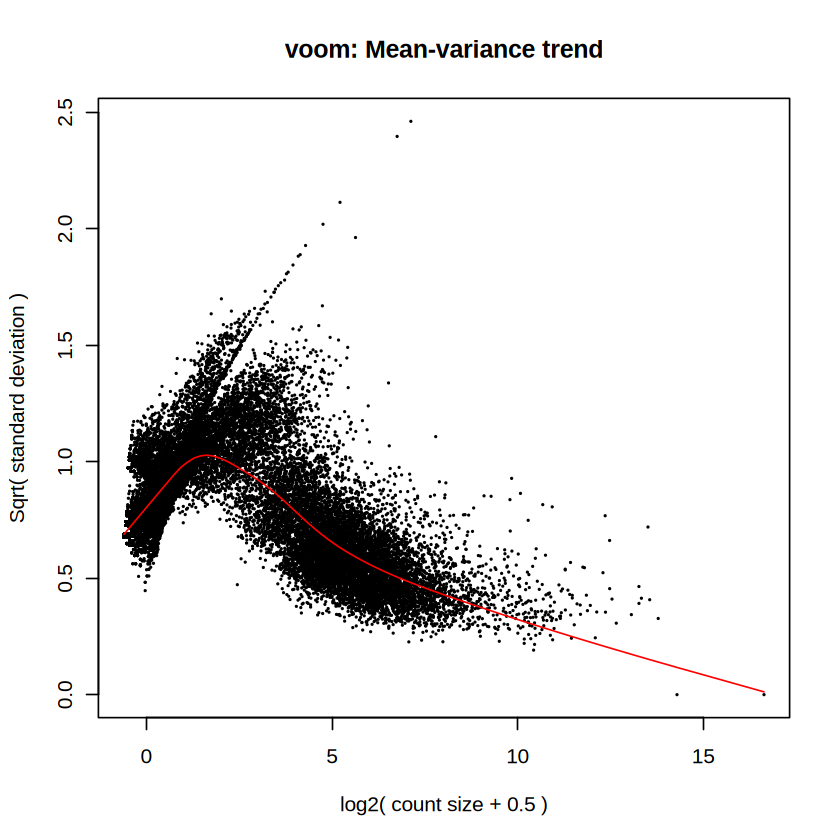

In [157]:
DGElist <- DGEList(counts = exp2, group = mm$group)
## 使用cpm值对低表达量的基因进行过滤
# keep_gene <- rowSums( cpm(DGElist) > 1 ) >= 2 ## 前面做过过滤，这里可做，也可以不做
# DGElist <- DGElist[ keep_gene, , keep.lib.sizes = FALSE ]

##使用edgeR中的calcNormFactors函数和limma中voom函数对矩阵进行标准化，也可以自行取log标准化
DGElist <- calcNormFactors( DGElist )
v <- voom(DGElist, design, plot = TRUE, normalize = "quantile")
ggsave("limma_deg.pdf",width = 6,height = 6)

##若是芯片数据、TPM数据或已标准化的数据，不需要再进行标准化，可直接从这里开始进行差异分析
fit <- lmFit(v, design)
cont.matrix <- makeContrasts(contrasts = c('RIR-Sham'), levels = design)
fit2 <- contrasts.fit(fit, cont.matrix)
fit2 <- eBayes(fit2)
nrDEG_limma_voom <- topTable(fit2, coef = 'RIR-Sham', n = Inf)
nrDEG_limma_voom <- na.omit(nrDEG_limma_voom)

#筛选显著性差异的基因
#这里使用logFC > 2 且adj.P.Val < 0.05的作为差异基因，可以根据需求改变阈值大小
nrDEG_limma_voom_signif <- nrDEG_limma_voom %>% filter(abs(logFC) > 1) %>% filter(adj.P.Val < 0.05)

In [176]:
# 筛选上下调，设定阈值
DEG_edgeR <- nrDEG_limma_voom
DEG_edgeR$gene <- rownames(DEG_edgeR)
fc_cutoff <- 1  # 阈值可调
pvalue <- 0.05    # p值越小，-log10(pvalue)越大，即越有信心认为差异显著
DEG_edgeR$regulated <- "normal"   # 新增regulated列，赋值“up”
loc_up <- intersect(which(DEG_edgeR$logFC>log2(fc_cutoff)),which(DEG_edgeR$adj.P.Val <pvalue))
loc_down <- intersect(which(DEG_edgeR$logFC < (-log2(fc_cutoff))),which(DEG_edgeR$adj.P.Val	<pvalue))
DEG_edgeR$regulated[loc_up] <- "up"    # []单索引代表列
DEG_edgeR$regulated[loc_down] <- "down"   # 满足上下调条件所在行对应的regulated列分别赋值为up和down
table(DEG_edgeR$regulated)


  down normal     up 
    14  24327     41 

In [ ]:
p <- ggplot(data=DEG_edgeR, aes(x=logFC, y=-log10(adj.P.Val),color=regulated)) + 
geom_point(alpha=0.5, size=2) + theme_set(theme_set(theme_bw(base_size=20))) + theme_bw() + 
xlab("log2FC") + ylab("-log10(adj.P.Val)") +
scale_colour_manual(values = c('#3288BD','grey','#D53E4F')) + 
geom_vline(xintercept=c(-(log2(2)),log2(2)),lty=4,col="black",lwd=0.8) +
geom_hline(yintercept = -log10(0.05),lty=4,col="black",lwd=0.8)
p
# ggsave("limma_DEG_Volcano_plot_raw.pdf",p,width = 7,height = 6)
# ggsave("limma_DEG_Volcano_plot_raw.pdf",p,width = 7,height = 6)
# 添加top基因
label <- DEG_edgeR[order(DEG_edgeR$adj.P.Val,decreasing = F)[1:10],]   # order函数对数据降序排序，提取表达量最大的前10个基因进行标签展示
p1 <- p + geom_point(size = 3, shape = 1, data = label) +
  ggrepel::geom_label_repel( aes(label = gene), data = label,color="black" )
p1

In [207]:
gene <- DEG_edgeR[which(DEG_edgeR$regulated!="normal"),]$gene

In [208]:
se <- NormalizeData(se)

Normalizing layer: counts



In [ ]:
exp <- as.data.frame(se@assays$RNA$data)
exp

In [210]:
exp <- subset(exp,select=c("Sham1","Sham2","Sham3","Sham4","Sham5","RIR1","RIR2","RIR3","RIR4","RIR5","RIR6"))

In [211]:
head(exp)

,Sham1,Sham2,Sham3,Sham4,Sham5,RIR1,RIR2,RIR3,RIR4,RIR5,RIR6
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0610005C13Rik,0.00000000,0.0000000,0.01021286,0.01007392,0.03128407,0.0000000,0.05062655,0.01837561,0.011864510,0.0000000,0.009432043
0610006L08Rik,0.00000000,0.0000000,0.01021286,0.00000000,0.00452952,0.0000000,0.00000000,0.01381326,0.007925294,0.0000000,0.000000000
0610009B22Rik,0.31250978,0.4833664,0.29173718,0.27297675,0.40807315,0.2223336,0.24448216,0.36817262,0.270267182,0.2755026,0.231594380
0610010F05Rik,0.08774787,0.0000000,0.08365532,0.15881586,0.09519697,0.1535722,0.23083382,0.12205686,0.091193886,0.1719640,0.141175418
0610010K14Rik,0.24305479,0.2190092,0.25662304,0.24166723,0.26556392,0.2709694,0.27123241,0.23082334,0.242560988,0.2618430,0.239083798
0610012D04Rik,0.00000000,0.0000000,0.00000000,0.00000000,0.00452952,0.0000000,0.00000000,0.00000000,0.003970498,0.0000000,0.000000000


In [212]:
exp1 <- exp[gene,]

In [213]:
gene

[1] "Cemip"          "Nqo1"           "Ctsl"           "Car3"          
 [5] "Agtr2"          "Ifi211"         "Pmel"           "Evi2a"         
 [9] "Crip1"          "Akr1b8"         "Itga6"          "Cd44"          
[13] "Clec12a"        "Ms4a4c"         "Psmb8"          "Fam25c"        
[17] "Gm19951"        "Pik3r5"         "Il2rg"          "Thbs2"         
[21] "Il31ra"         "Vav1"           "Irf8"           "Tyrp1"         
[25] "Hmgn3"          "Cox5b"          "Snx20"          "Rerg"          
[29] "Tnfrsf26"       "Tgfbi"          "Zbp1"           "Slamf7"        
[33] "Ms4a6b"         "9930111J21Rik2" "Tmprss11g"      "Gsta2"         
[37] "Syt6"           "Stom"           "Fam162a"        "Gm48099"       
[41] "Pik3cd"         "Lgmn"           "Kazald1"        "Tbc1d9"        
[45] "Ccl8"           "Tmem173"        "Cnmd"           "Adh6a"         
[49] "Cd93"           "Gbp5"           "Myo1f"          "H2-D1"         
[53] "Cdk8"           "Camk1d"         "Rpl41"

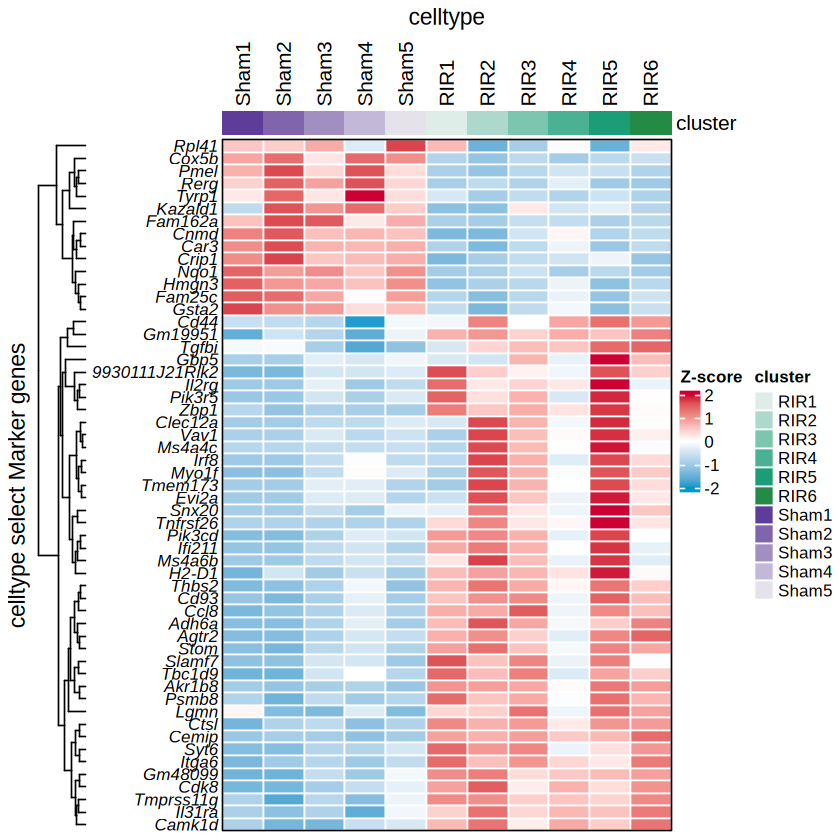

In [251]:
# Z-score
htdf <- t(scale(t(exp1),scale = T,center = T))

# color
col_fun = colorRamp2(c(-2, 0, 2), c("#0099CC", "white", "#CC0033"))

# top annotation
column_ha = HeatmapAnnotation(cluster = colnames(htdf),col = list(cluster = cols))
# plot
p <- Heatmap(htdf,
        name = "Z-score",
        cluster_columns = F,cluster_rows = T,
        row_title = "celltype select Marker genes",
        column_title = "celltype",
        row_names_gp = gpar(fontface = 'italic',fontsize = 10),
        row_names_side = 'left',
        border = T,
        rect_gp = gpar(col = "white", lwd = 1),
        column_names_side = 'top',
        column_names_rot = 90,
        top_annotation = column_ha,
        # column_split = paste('clsuter ',0:8,sep = ''),
        col = col_fun)
p

pdf 
  2

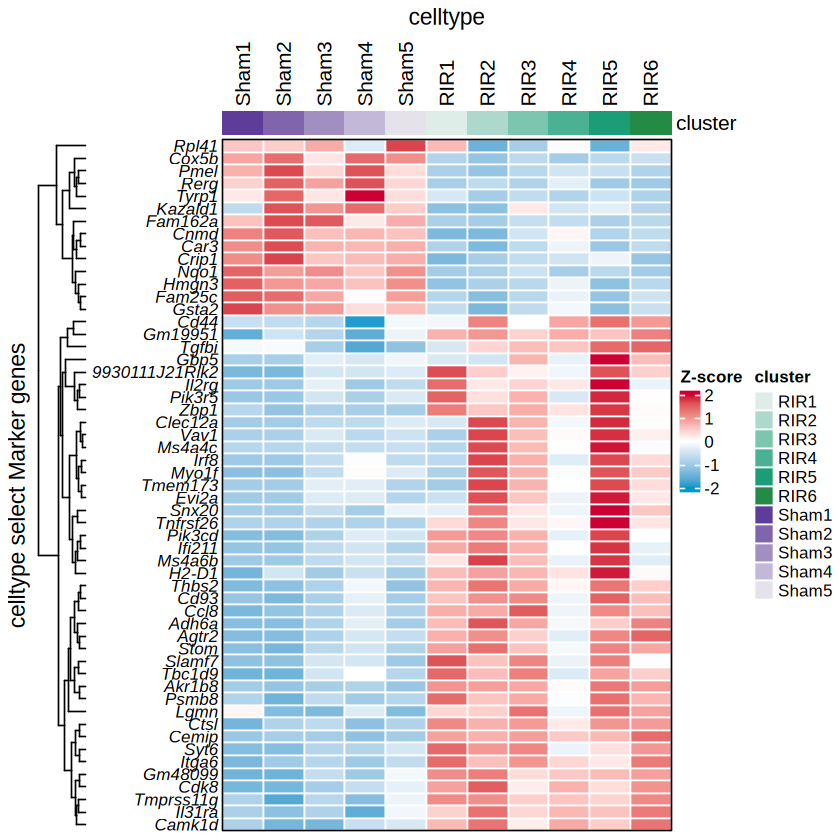

In [252]:
p
pdf("Cornea_deg_heatmap.pdf",width = 6,height = 9)
print(p)
dev.off()

In [240]:
deg2 <- deg1[which(abs(deg1$avg_log2FC)>0.5&deg1$p_val_adj< 0.05),]

In [241]:
up <-  deg2[which(deg2$avg_log2FC>0),]$gene
down <- deg2[which(deg2$avg_log2FC<0),]$gene

In [242]:
length(up)
length(down)

[1] 374

[1] 128

In [243]:
library(clusterProfiler)  # GO和KEGG富集分析
library(org.Hs.eg.db)     # 人类注释数据库
library(org.Mm.eg.db)     # 人类注释数据库
library(GSEABase)    # GESA富集分析
library(ggplot2)     # 可视化绘图
library(tidyverse)   # 数据处理和整理

In [244]:

ego <- enrichGO(gene=up, OrgDb= 'org.Mm.eg.db', keyType='SYMBOL', ont="ALL", pvalueCutoff= 1,qvalueCutoff= 1)

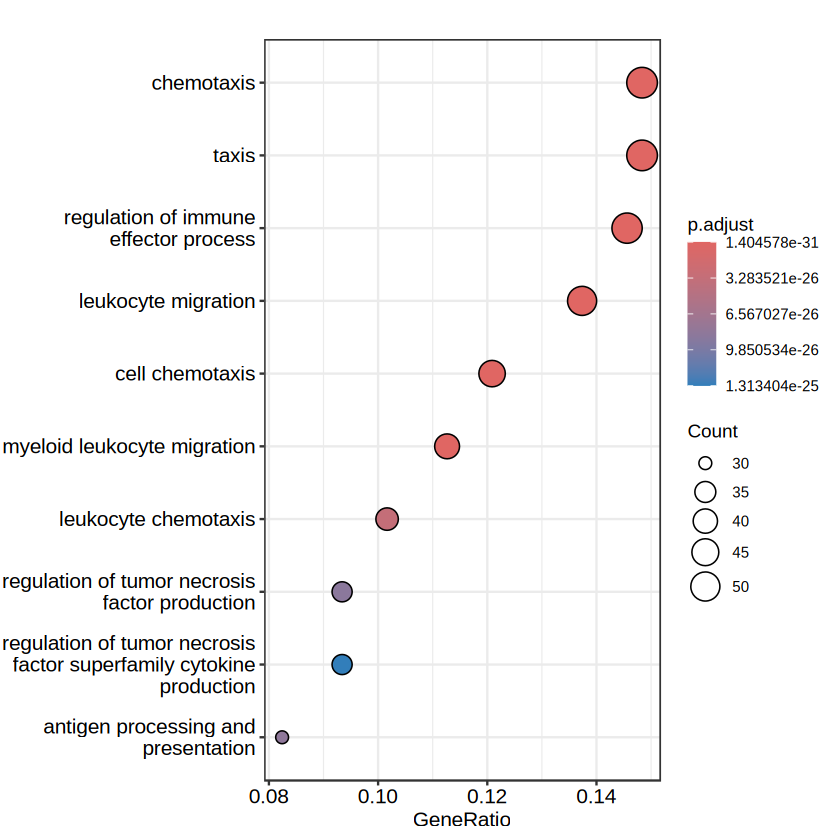

In [245]:
p2 <- dotplot(ego, showCategory=10)
p2

In [246]:
ggsave("Cornea_upgene_enrichGO_dotplot.pdf",p2,width=7,height=8)

In [247]:
go <- ego@result
go1 <- go[which(go$p.adjust<0.05&go$Count>4),]
write.csv(go1,"up_gene_GO.csv")

In [248]:

ego <- enrichGO(gene=down, OrgDb= 'org.Mm.eg.db', keyType='SYMBOL', ont="ALL", pvalueCutoff= 1,qvalueCutoff= 1)

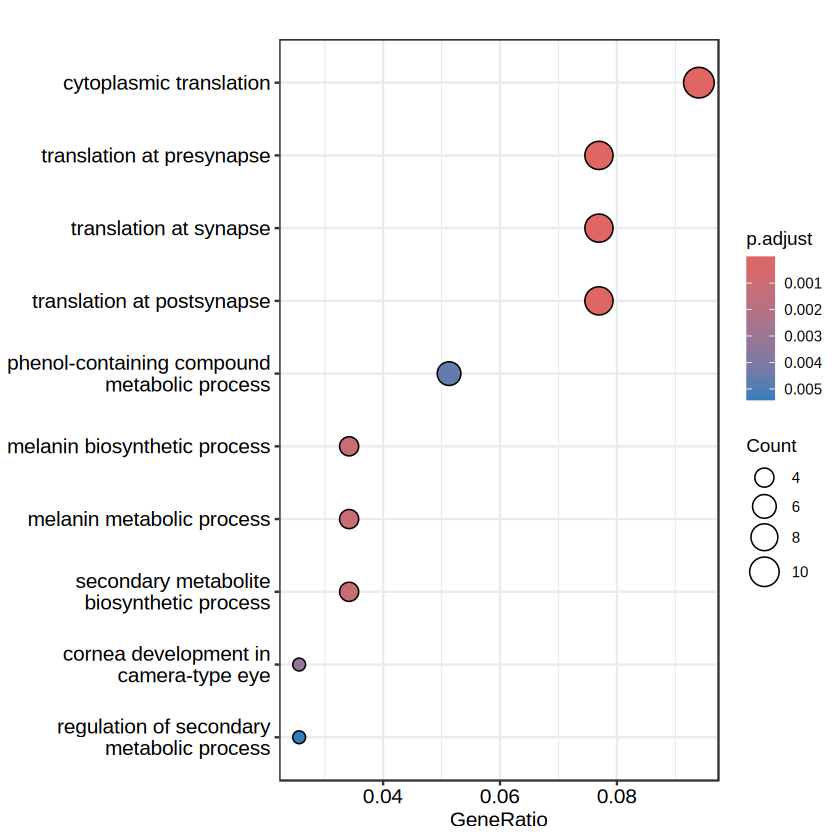

In [249]:
p2 <- dotplot(ego, showCategory=10)
p2

ggsave("Cornea_downgene_enrichGO_dotplot.pdf",p2,width=7,height=8)

In [250]:
go <- ego@result
go1 <- go[which(go$p.adjust<0.05&go$Count>4),]
write.csv(go1,"down_gene_GO.csv")

In [253]:
####sup5
setwd("/home/ljpuser/disk1/pienapple/03eye/30data_st_del/04imeta_fige_plot_update/09sup5_cb/")

In [254]:
sp1 <- subset(sp,subset=area%in%c("CB","Iris"))

In [ ]:
m <- as.matrix(table(as.character(sp1$sample), sp1$celltype))
m
plot_df <- as.data.frame(m)
head(plot_df)

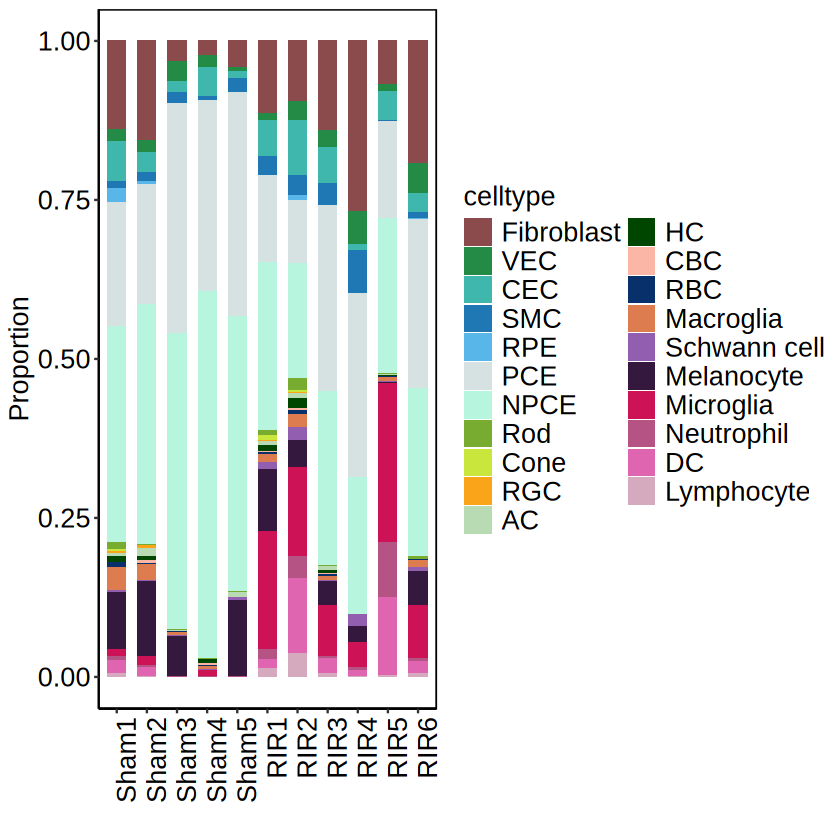

In [263]:
colnames(plot_df) <- c('type','celltype','sum')
    plot_df$celltype <- factor(plot_df$celltype,levels = cell_order)
  plot_df$type <- factor(plot_df$type,levels = sa)
    p1 <- ggplot(plot_df, mapping = aes(type,sum,fill=celltype))+geom_bar(stat='identity',position="fill",width = 0.6)+
    labs(x = "",y = 'Proportion') +theme(axis.title =element_text(size = 16),axis.text =element_text(size = 14, color = 'black'))+
    theme(
        plot.title= element_text(color = 'black', size   = 20, hjust = 0.5),
        plot.subtitle = element_text(color = 'black', size   = 16,hjust = 0.5),
        plot.caption  = element_text(color = 'black', size   = 16,face = 'italic', hjust = 1),
        axis.text.x   = element_text(color = 'black', size = 16, angle = 90,hjust = 1),
        axis.text.y   = element_text(color = 'black', size = 16, angle = 0),
        axis.title.x  = element_text(color = 'black', size = 16, angle = 0),
        axis.title.y  = element_text(color = 'black', size = 16, angle = 90),
        legend.title  = element_text(color = 'black', size  = 16),
        legend.text   = element_text(color = 'black', size   = 16),
        axis.line.y = element_line(color = 'black', linetype = 'solid'),
        axis.line.x = element_line (color = 'black',linetype = 'solid'), 
        panel.background=element_rect(fill="white"))+scale_fill_manual(values =cols)+
    theme(panel.border = element_rect(fill = NA,color = "black",size=0.5,linetype = "solid"))
    print(p1)
ggsave("CBIRIS_stat.pdf",p1,width = 7,height = 6)

In [306]:
sp1@meta.data$sample <- factor(sp1@meta.data$sample,levels = c("Sham1","Sham2","Sham3","Sham4","Sham5","RIR1","RIR2","RIR3","RIR4","RIR5","RIR6"))

In [307]:
###deg
Idents(sp1) <- as.factor(sp1@meta.data$group)
sp1 <- ScaleData(sp1, features = rownames(sp1))
deg <- FindAllMarkers(sp1,slot="scale.data")
deg1 <- subset(deg,subset = cluster=="RIR")

Centering and scaling data matrix

Calculating cluster RIR

Calculating cluster Sham



In [308]:
library(circlize)
library(ComplexHeatmap)

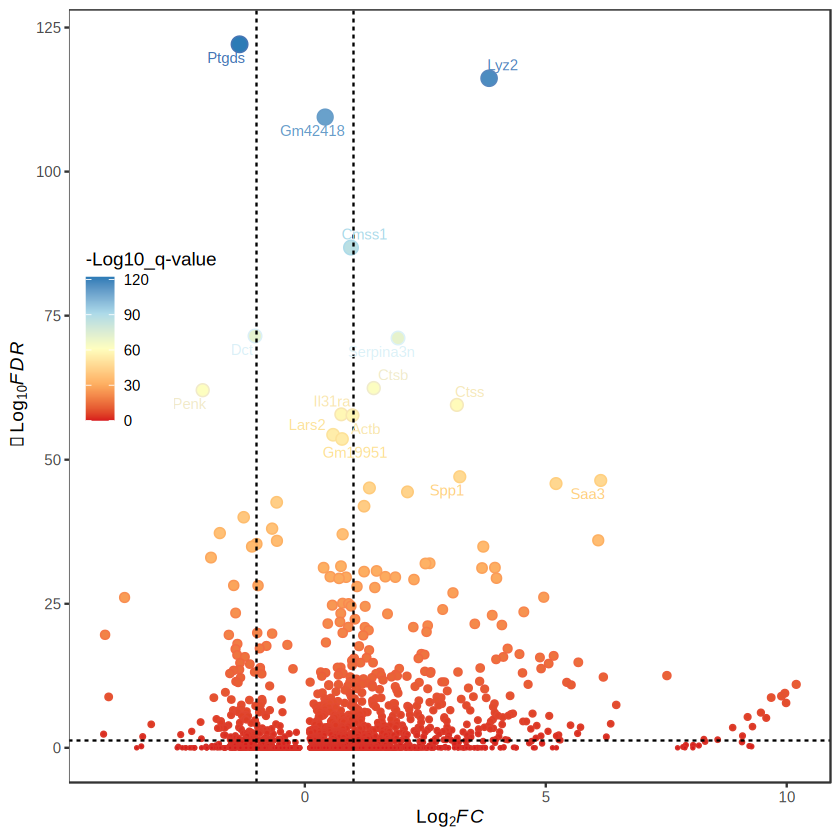

In [309]:
p3 <- gradual_volcano(deg1,
                      x = "avg_log2FC",
                      y = "p_val_adj",
                      label = "gene",
                      label_number = 15,
                      fills = brewer.pal(5, "RdYlBu"),colors = brewer.pal(8, "RdYlBu"),
                      output = FALSE)
p3

In [310]:
pdf("CBiris_deg.pdf",width=6,height=6)
print(p3)
dev.off()

pdf 
  2

In [312]:
gene <- deg1[which(abs(deg1$avg_log2FC)>1.2&deg1$p_val_adj< 0.05&deg1$`pct.1`>0.11),]$gene
length(gene)

[1] 35

In [313]:
####heatmap plot 
mean_gene_exp<-AverageExpression(sp1,features=gene,group.by='sample',slot='data')%>%data.frame()%>%as.matrix()
unique(sp1@meta.data$sample)
colnames(mean_gene_exp)

[1] Sham2 Sham1 RIR1  RIR2  RIR3  RIR4  Sham3 RIR5  Sham4 RIR6  Sham5
Levels: Sham1 Sham2 Sham3 Sham4 Sham5 RIR1 RIR2 RIR3 RIR4 RIR5 RIR6

[1] "RNA.Sham1" "RNA.Sham2" "RNA.Sham3" "RNA.Sham4" "RNA.Sham5" "RNA.RIR1" 
 [7] "RNA.RIR2"  "RNA.RIR3"  "RNA.RIR4"  "RNA.RIR5"  "RNA.RIR6"

In [314]:
cols <- c("Sham1"="#5E3C99","Sham2"="#8065AD","Sham3"="#A28FC2","Sham4"="#C3B8D7","Sham5"="#E6E2EC","RIR1"="#DEEDE8","RIR2"="#ADD9CC","RIR3"="#7CC5AF","RIR4"="#4BB193","RIR5"="#1B9E77","RIR5"="#0F7A5C","RIR6"="#238b45")

[1] "Sham1" "Sham2" "Sham3" "Sham4" "Sham5" "RIR1"  "RIR2"  "RIR3"  "RIR4" 
[10] "RIR5"  "RIR6"

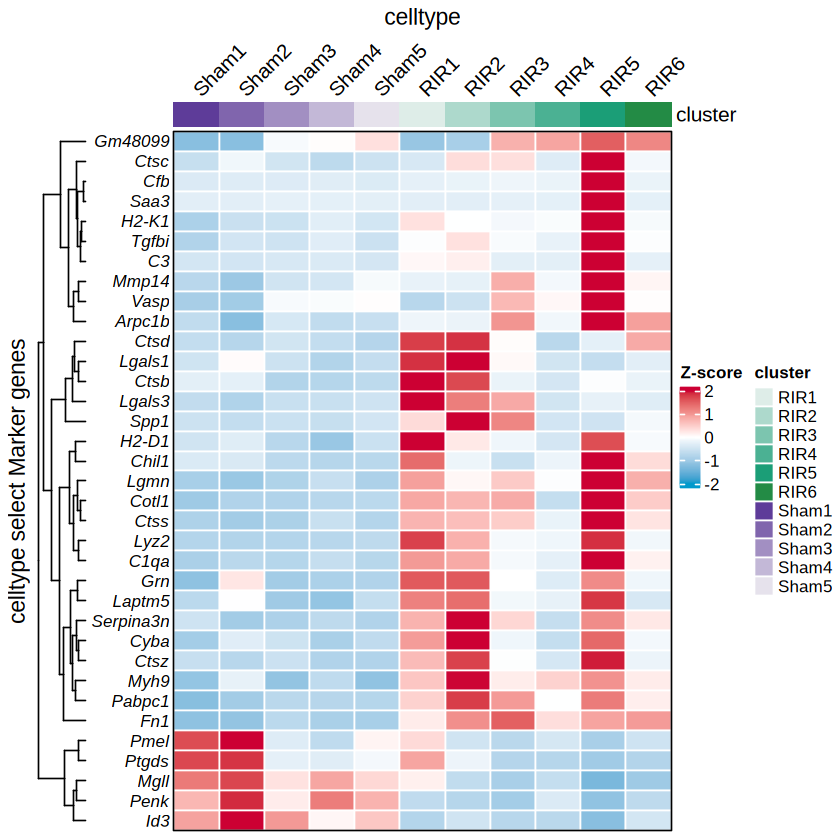

In [315]:
colnames(mean_gene_exp) <- sa
colnames(mean_gene_exp)
m <- t(subset(as.data.frame(t(mean_gene_exp)),select = gene))
# Z-score
htdf <- t(scale(t(m),scale = T,center = T))

# color
col_fun = colorRamp2(c(-2, 0, 2), c("#0099CC", "white", "#CC0033"))

# top annotation
column_ha = HeatmapAnnotation(cluster = colnames(htdf),col = list(cluster = cols))
# plot
p <- Heatmap(htdf,
        name = "Z-score",
        cluster_columns = F,cluster_rows = T,
        row_title = "celltype select Marker genes",
        column_title = "celltype",
        row_names_gp = gpar(fontface = 'italic',fontsize = 10),
        row_names_side = 'left',
        border = T,
        rect_gp = gpar(col = "white", lwd = 1),
        column_names_side = 'top',
        column_names_rot = 45,
        top_annotation = column_ha,
        # column_split = paste('clsuter ',0:8,sep = ''),
        col = col_fun)
p

In [285]:
####bulk ###let doit
n=0
for(i in unique(sp1@meta.data$sample)){
    n=n+1
    pbmc <- subset(sp1,subset=sample==i)
        counts <- data.frame(rowSums(as.matrix(pbmc@assays$RNA$counts)))
        colnames(counts) <- i
        m <- as.data.frame(i)
        colnames(m) <- "names"
        m$sample <- i
        if(n==1){
            counts1 <- counts
            m1 <- m
        }
        else{
            counts1 <- merge(counts1,counts,all=TRUE,by=0)
            rownames(counts1) <- counts1$Row.names
            counts1 <- counts1[,-1]
            m1 <- rbind(m1,m)
        }
    }

In [286]:
m <- as.data.frame(unique(sp1@meta.data$sample))
rownames(m) <- m[,1]
colnames(m) <- "group"
m$group <- substr(m$group,1,3)
m$batch <- c("1","1","1","1","2","2","2","2","2","2","2")
m$group <- str_replace(m$group,"Sha","Sham")
m$sample <- rownames(m)
m

,group,batch,sample
,<chr>,<chr>,<chr>
Sham2,Sham,1,Sham2
Sham1,Sham,1,Sham1
RIR1,RIR,1,RIR1
RIR2,RIR,1,RIR2
RIR3,RIR,2,RIR3
RIR4,RIR,2,RIR4
Sham3,Sham,2,Sham3
RIR5,RIR,2,RIR5
Sham4,Sham,2,Sham4


In [287]:
m1$group <- substr(m1$names,1,3)
m1$group <- str_replace(m1$group,"Sha","Sham")
m1$batch <- "NA"
for(i in unique(m$sample)){
    m1[which(m1$sample==i),]$batch <- m[which(m$sample==i),]$batch
}

In [288]:
exp <- counts1
mm <- m

In [289]:
####batch
mod = model.matrix(~mm$group)
exp2 = ComBat_seq(counts = as.matrix(exp), batch = factor(mm$batch),group = factor(mm$group))
class(exp2)
dat = log2(edgeR::cpm(exp2)+1)

Found 2 batches
Using full model in ComBat-seq.
Adjusting for 1 covariate(s) or covariate level(s)
Estimating dispersions
Fitting the GLM model
Shrinkage off - using GLM estimates for parameters
Adjusting the data


[1] "matrix" "array"

In [290]:
se <- CreateSeuratObject(counts = exp2,meta.data = mm)

In [ ]:
# 构建线性模型，0代表x线性模型的截距为0
design <- model.matrix(~0+mm$group)  # 生成设计矩阵，又叫分组矩阵，分组依据是factor的level水平
rownames(design) <- colnames(exp2)  # 设计矩阵的行名，与表达矩阵的列名一一对应
colnames(design) <- levels(factor(mm$group))   # 设计矩阵的列名，与生成的分组信息一致
design

In [ ]:
DEG <- DGEList(counts=exp2,group=factor(mm$group))
DEG  
# 归一化基因表达分布
DEG <- calcNormFactors(DEG)
# 计算线性模型的参数
DEG <- estimateGLMCommonDisp(DEG,design)
DEG <- estimateGLMTrendedDisp(DEG, design)
DEG <- estimateGLMTagwiseDisp(DEG, design)
# 拟合线性模型
fit <- glmFit(DEG, design)

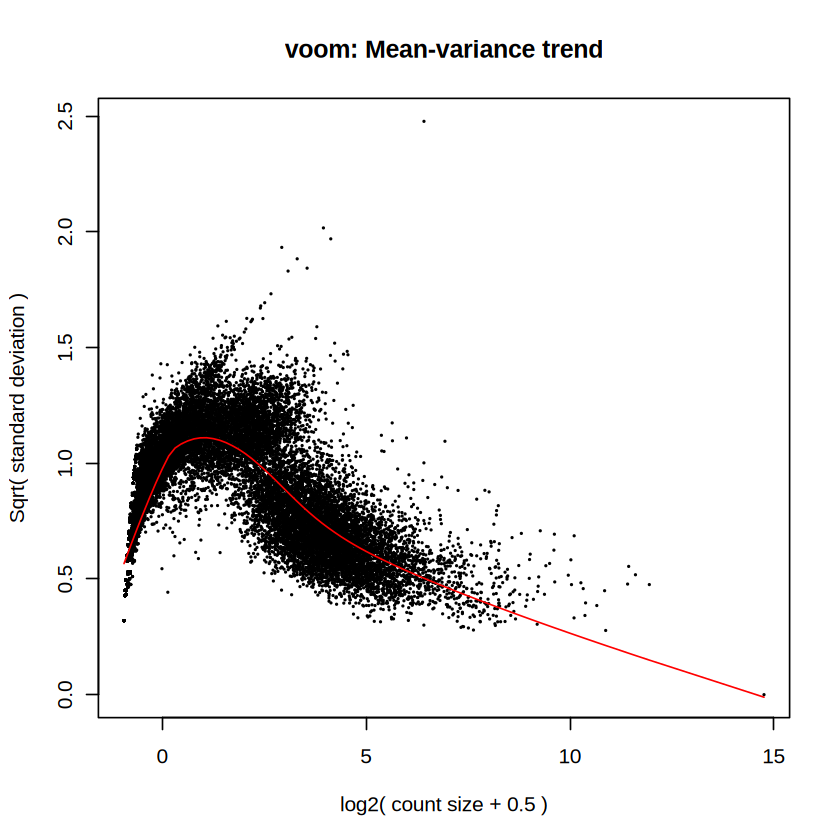

In [293]:
DGElist <- DGEList(counts = exp2, group = mm$group)
## 使用cpm值对低表达量的基因进行过滤
# keep_gene <- rowSums( cpm(DGElist) > 1 ) >= 2 ## 前面做过过滤，这里可做，也可以不做
# DGElist <- DGElist[ keep_gene, , keep.lib.sizes = FALSE ]

##使用edgeR中的calcNormFactors函数和limma中voom函数对矩阵进行标准化，也可以自行取log标准化
DGElist <- calcNormFactors( DGElist )
v <- voom(DGElist, design, plot = TRUE, normalize = "quantile")
ggsave("limma_deg.pdf",width = 6,height = 6)

##若是芯片数据、TPM数据或已标准化的数据，不需要再进行标准化，可直接从这里开始进行差异分析
fit <- lmFit(v, design)
cont.matrix <- makeContrasts(contrasts = c('RIR-Sham'), levels = design)
fit2 <- contrasts.fit(fit, cont.matrix)
fit2 <- eBayes(fit2)
nrDEG_limma_voom <- topTable(fit2, coef = 'RIR-Sham', n = Inf)
nrDEG_limma_voom <- na.omit(nrDEG_limma_voom)

#筛选显著性差异的基因
#这里使用logFC > 2 且adj.P.Val < 0.05的作为差异基因，可以根据需求改变阈值大小
nrDEG_limma_voom_signif <- nrDEG_limma_voom %>% filter(abs(logFC) > 1) %>% filter(adj.P.Val < 0.05)

In [297]:
# 筛选上下调，设定阈值
DEG_edgeR <- nrDEG_limma_voom
DEG_edgeR$gene <- rownames(DEG_edgeR)
fc_cutoff <- 2  # 阈值可调
pvalue <- 0.1   # p值越小，-log10(pvalue)越大，即越有信心认为差异显著
DEG_edgeR$regulated <- "normal"   # 新增regulated列，赋值“up”
loc_up <- intersect(which(DEG_edgeR$logFC>log2(fc_cutoff)),which(DEG_edgeR$adj.P.Val <pvalue))
loc_down <- intersect(which(DEG_edgeR$logFC < (-log2(fc_cutoff))),which(DEG_edgeR$adj.P.Val	<pvalue))
DEG_edgeR$regulated[loc_up] <- "up"    # []单索引代表列
DEG_edgeR$regulated[loc_down] <- "down"   # 满足上下调条件所在行对应的regulated列分别赋值为up和down
table(DEG_edgeR$regulated)


  down normal     up 
   188  23678    516 

In [ ]:
# 筛选上调基因，按 P.Value 升序排列，取前 15 行
up_sig <- DEG_edgeR %>%
  filter(regulated == "up") %>%
  arrange(adj.P.Val	) %>%
  head(20)

# 筛选下调基因，按 P.Value 升序排列，取前 15 行
down_sig <- DEG_edgeR %>%
  filter(regulated == "down") %>%
  arrange(adj.P.Val	) %>%
  head(20)

# 查看结果
print(up_sig[, c("gene", "logFC", "P.Value", "adj.P.Val")])
print(down_sig[, c("gene", "logFC", "P.Value", "adj.P.Val")])

In [301]:
up_genes <- up_sig$gene
down_genes <- down_sig$gene

In [325]:
gene <- c(up_sig$gene,down_sig$gene)
gene <- c('Ccl7','Arhgap11a','Tlr13','Plaur','Arhgap30','Plbd1','Gm26811','Ptpn7','Mmp8','Cyp27a1',
          'Nuf2','Card9','Ccl9','Bcl2a1b','Mlkl',
          'Pus7l','Wdfy4','Bcl3','Socs3','Tnfaip8l2','Atp1a2','Folr1','Slc2a1','Ppp1r1a','Nectin1','Wfdc1','Spock1','Fhdc1',
          'Col9a1','Slc39a12','Xkr4','Slc4a4','Dkk3','Prcd','Plekha7','Rapsn','Folh1','Slc35f3','Slc38a3')


In [326]:
####heatmap plot 
mean_gene_exp<-AverageExpression(sp1,features=gene,group.by='sample',slot='data')%>%data.frame()%>%as.matrix()
unique(sp1@meta.data$sample)
colnames(mean_gene_exp)

[1] Sham2 Sham1 RIR1  RIR2  RIR3  RIR4  Sham3 RIR5  Sham4 RIR6  Sham5
Levels: Sham1 Sham2 Sham3 Sham4 Sham5 RIR1 RIR2 RIR3 RIR4 RIR5 RIR6

[1] "RNA.Sham1" "RNA.Sham2" "RNA.Sham3" "RNA.Sham4" "RNA.Sham5" "RNA.RIR1" 
 [7] "RNA.RIR2"  "RNA.RIR3"  "RNA.RIR4"  "RNA.RIR5"  "RNA.RIR6"

In [327]:
colnames(mean_gene_exp) <- sa

[1] "Sham1" "Sham2" "Sham3" "Sham4" "Sham5" "RIR1"  "RIR2"  "RIR3"  "RIR4" 
[10] "RIR5"  "RIR6"

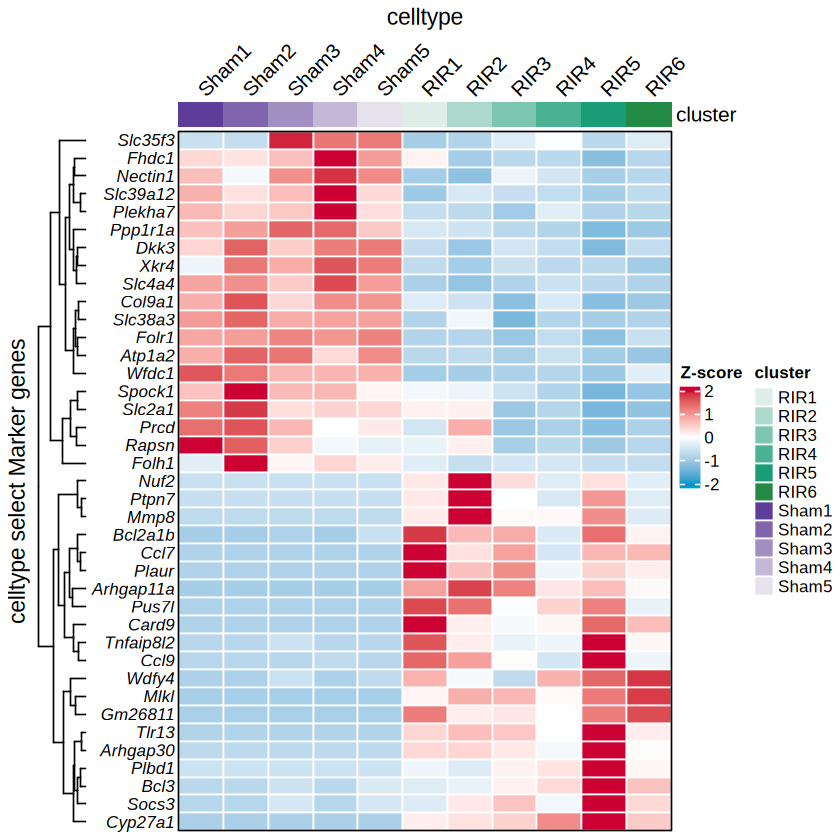

In [328]:
colnames(mean_gene_exp)
m <- t(subset(as.data.frame(t(mean_gene_exp)),select = gene))
# Z-score
htdf <- t(scale(t(m),scale = T,center = T))

# color
col_fun = colorRamp2(c(-2, 0, 2), c("#0099CC", "white", "#CC0033"))

# top annotation
column_ha = HeatmapAnnotation(cluster = colnames(htdf),col = list(cluster = cols))
# plot
p <- Heatmap(htdf,
        name = "Z-score",
        cluster_columns = F,cluster_rows = T,
        row_title = "celltype select Marker genes",
        column_title = "celltype",
        row_names_gp = gpar(fontface = 'italic',fontsize = 10),
        row_names_side = 'left',
        border = T,
        rect_gp = gpar(col = "white", lwd = 1),
        column_names_side = 'top',
        column_names_rot = 45,
        top_annotation = column_ha,
        # column_split = paste('clsuter ',0:8,sep = ''),
        col = col_fun)
p

pdf 
  2

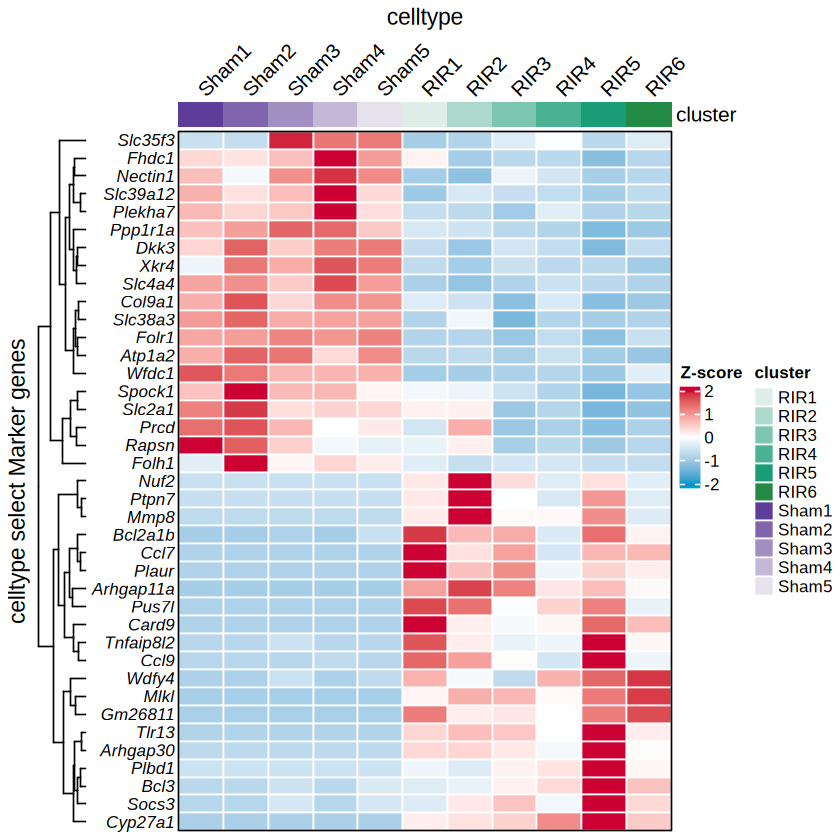

In [329]:
p
pdf("CB_iris_deg_heatmap.pdf",width = 6,height = 9)
print(p)
dev.off()

In [330]:
deg2 <- deg1[which(abs(deg1$avg_log2FC)>1&deg1$p_val_adj< 0.05),]

In [368]:
up <-  deg2[which(deg2$avg_log2FC>0),]$gene
down <- deg2[which(deg2$avg_log2FC<0),]$gene

In [369]:
library(clusterProfiler)  # GO和KEGG富集分析
library(org.Hs.eg.db)     # 人类注释数据库
library(org.Mm.eg.db)     # 人类注释数据库
library(GSEABase)    # GESA富集分析
library(ggplot2)     # 可视化绘图
library(tidyverse)   # 数据处理和整理

In [372]:

ego <- enrichGO(gene=up, OrgDb= 'org.Mm.eg.db', keyType='SYMBOL', ont="BP", pvalueCutoff= 0.05,qvalueCutoff= 1)

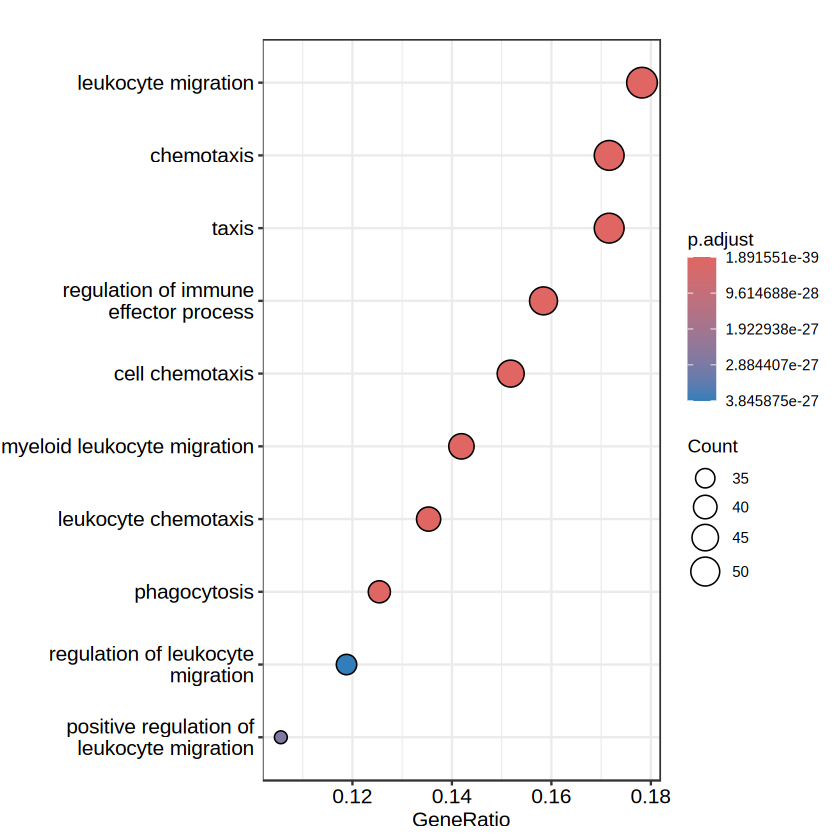

In [373]:
p2 <- dotplot(ego, showCategory=10)
p2

In [374]:
ggsave("CBiris_upgene_enrichGO_dotplot.pdf",p2,width=7,height=8)

In [375]:
go <- ego@result
go1 <- go[which(go$p.adjust<0.05&go$Count>3),]
write.csv(go1,"up_gene_GO.csv")

In [376]:

ego <- enrichGO(gene=down, OrgDb= 'org.Mm.eg.db', keyType='SYMBOL', ont="BP", pvalueCutoff= 0.05,qvalueCutoff= 1)

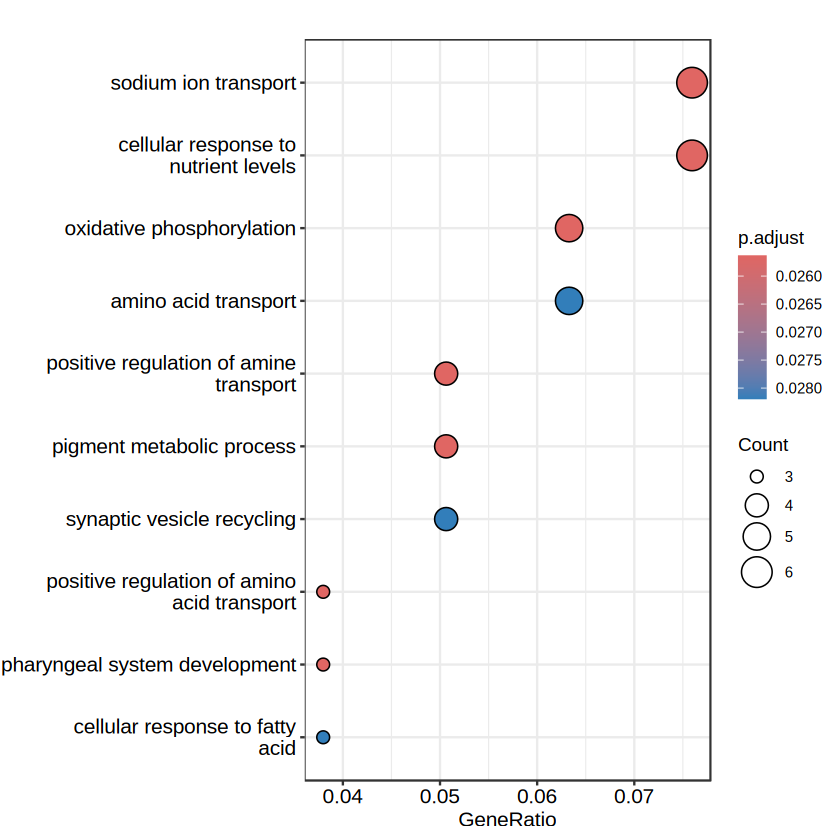

In [377]:
p2 <- dotplot(ego, showCategory=10)
p2

ggsave("CBiris_downgene_enrichGO_dotplot.pdf",p2,width=7,height=8)

In [397]:
go <- ego@result
go1 <- go[which(go$p.adjust<0.05&go$Count>5),]
write.csv(go1,"down_gene_GO.csv")

In [400]:
down <- read.csv("down_gene_GO.csv",row.names = 1)
up <- read.csv("up_gene_GO.csv",row.names = 1)

In [401]:
down

,ID,Description,GeneRatio,BgRatio,RichFactor,FoldEnrichment,zScore,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>
GO:0006814,GO:0006814,sodium ion transport,6/79,260/28928,0.02307692,8.450243,6.314781,7.989325e-05,0.02563311,0.01886764,Atp1a2/Slc4a5/Slc4a4/Sgk1/Slc6a9/Slc38a3,6
GO:0031669,GO:0031669,cellular response to nutrient levels,6/79,275/28928,0.02181818,7.989321,6.094192,1.086450e-04,0.02563311,0.01886764,Penk/Folr1/Dapl1/Lpl/Slc38a3/Fam107a,6
GO:0015711,GO:0015711,organic anion transport,7/79,477/28928,0.01467505,5.373670,5.040299,3.305955e-04,0.02819594,0.02075405,Folr1/Slc4a5/Slc4a4/Slc6a9/Cck/Slc38a3/Abat,7
GO:0015980,GO:0015980,energy derivation by oxidation of organic compounds,6/79,380/28928,0.01578947,5.781746,4.910099,6.125996e-04,0.03081079,0.02267875,Cox8b/Ppp1r1a/Chchd10/Cox7a2/Ndufa13/Uqcr10,6
GO:0043010,GO:0043010,camera-type eye development,6/79,423/28928,0.01418440,5.194003,4.547139,1.066963e-03,0.03361409,0.02474216,Slc4a5/Slc38a8/Hes1/Tbx2/Nectin1/Megf11,6
GO:0001558,GO:0001558,regulation of cell growth,6/79,456/28928,0.01315789,4.818121,4.300540,1.564068e-03,0.03721947,0.02739596,Mgll/Wfdc1/Sgk1/Ndufa13/Fam107a/Myo5b,6
GO:0001654,GO:0001654,eye development,6/79,473/28928,0.01268499,4.644954,4.182570,1.880673e-03,0.03920480,0.02885729,Slc4a5/Slc38a8/Hes1/Tbx2/Nectin1/Megf11,6
GO:0150063,GO:0150063,visual system development,6/79,476/28928,0.01260504,4.615679,4.162333,1.941250e-03,0.03995535,0.02940975,Slc4a5/Slc38a8/Hes1/Tbx2/Nectin1/Megf11,6
GO:0048880,GO:0048880,sensory system development,6/79,483/28928,0.01242236,4.548785,4.115761,2.088352e-03,0.04114030,0.03028194,Slc4a5/Slc38a8/Hes1/Tbx2/Nectin1/Megf11,6


In [402]:
plotdata <- down

In [405]:
plotdata$Signif <- " "
plotdata[which(plotdata$`p.adjust`>=0.01&plotdata$`p.adjust`<0.05),]$Signif <- "*"
# plotdata[which(plotdata$`p.adjust`>=0.001&plotdata$`p.adjust`<0.01),]$Signif <- "**"
# plotdata[which(plotdata$`p.adjust`<0.001),]$Signif <- "***"

plotdata$geneRatio <- plotdata$Count/79

In [406]:
unique(plotdata$Signif)

[1] "*"

In [407]:
plotdata <- plotdata %>%
  arrange(p.adjust) %>%
  head(10)

In [408]:
plotdata <- plotdata[order(plotdata$geneRatio),]
lev <- plotdata$Description

In [418]:
plotdata$Description <- factor(plotdata$Description,levels = rev(lev1))

In [419]:
plotdata$Description

[1] sodium ion transport                               
 [2] cellular response to nutrient levels               
 [3] energy derivation by oxidation of organic compounds
 [4] camera-type eye development                        
 [5] regulation of cell growth                          
 [6] eye development                                    
 [7] visual system development                          
 [8] sensory system development                         
 [9] regulation of neurogenesis                         
[10] organic anion transport                            
10 Levels: sodium ion transport ... organic anion transport

In [420]:
plotdata

,ID,Description,GeneRatio,BgRatio,RichFactor,FoldEnrichment,zScore,pvalue,p.adjust,qvalue,geneID,Count,Signif,geneRatio
,<chr>,<fct>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>,<dbl>
GO:0006814,GO:0006814,sodium ion transport,6/79,260/28928,0.02307692,8.450243,6.314781,7.989325e-05,0.02563311,0.01886764,Atp1a2/Slc4a5/Slc4a4/Sgk1/Slc6a9/Slc38a3,6,*,0.07594937
GO:0031669,GO:0031669,cellular response to nutrient levels,6/79,275/28928,0.02181818,7.989321,6.094192,1.086450e-04,0.02563311,0.01886764,Penk/Folr1/Dapl1/Lpl/Slc38a3/Fam107a,6,*,0.07594937
GO:0015980,GO:0015980,energy derivation by oxidation of organic compounds,6/79,380/28928,0.01578947,5.781746,4.910099,6.125996e-04,0.03081079,0.02267875,Cox8b/Ppp1r1a/Chchd10/Cox7a2/Ndufa13/Uqcr10,6,*,0.07594937
GO:0043010,GO:0043010,camera-type eye development,6/79,423/28928,0.01418440,5.194003,4.547139,1.066963e-03,0.03361409,0.02474216,Slc4a5/Slc38a8/Hes1/Tbx2/Nectin1/Megf11,6,*,0.07594937
GO:0001558,GO:0001558,regulation of cell growth,6/79,456/28928,0.01315789,4.818121,4.300540,1.564068e-03,0.03721947,0.02739596,Mgll/Wfdc1/Sgk1/Ndufa13/Fam107a/Myo5b,6,*,0.07594937
GO:0001654,GO:0001654,eye development,6/79,473/28928,0.01268499,4.644954,4.182570,1.880673e-03,0.03920480,0.02885729,Slc4a5/Slc38a8/Hes1/Tbx2/Nectin1/Megf11,6,*,0.07594937
GO:0150063,GO:0150063,visual system development,6/79,476/28928,0.01260504,4.615679,4.162333,1.941250e-03,0.03995535,0.02940975,Slc4a5/Slc38a8/Hes1/Tbx2/Nectin1/Megf11,6,*,0.07594937
GO:0048880,GO:0048880,sensory system development,6/79,483/28928,0.01242236,4.548785,4.115761,2.088352e-03,0.04114030,0.03028194,Slc4a5/Slc38a8/Hes1/Tbx2/Nectin1/Megf11,6,*,0.07594937
GO:0050767,GO:0050767,regulation of neurogenesis,6/79,485/28928,0.01237113,4.530027,4.102618,2.131892e-03,0.04114030,0.03028194,Dct/Sgk1/Hes1/Id1/Tenm4/Myo5b,6,*,0.07594937


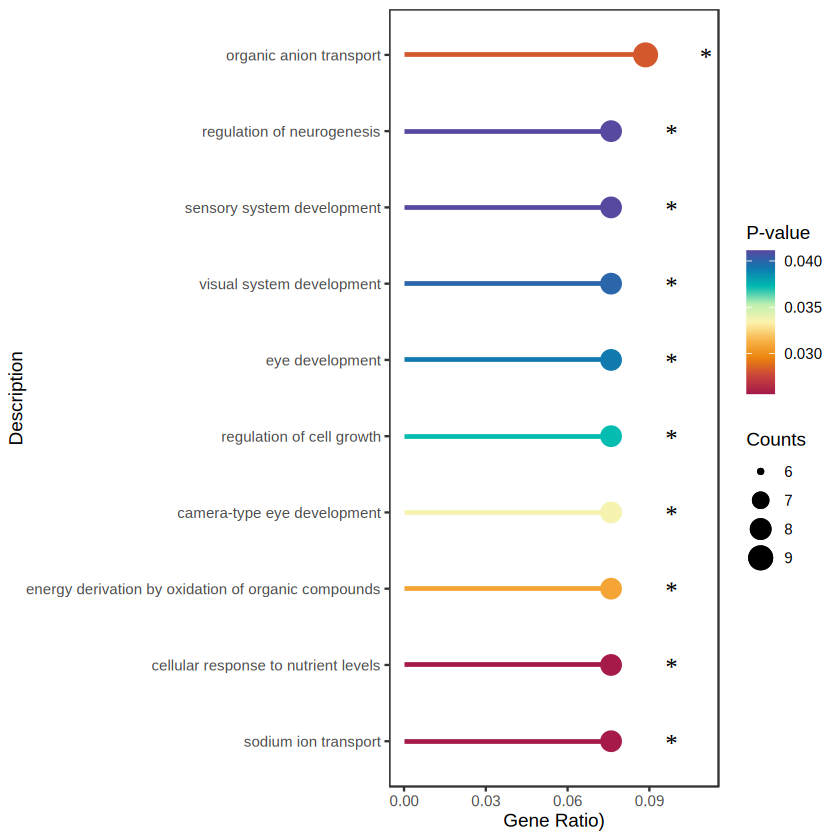

pdf 
  2

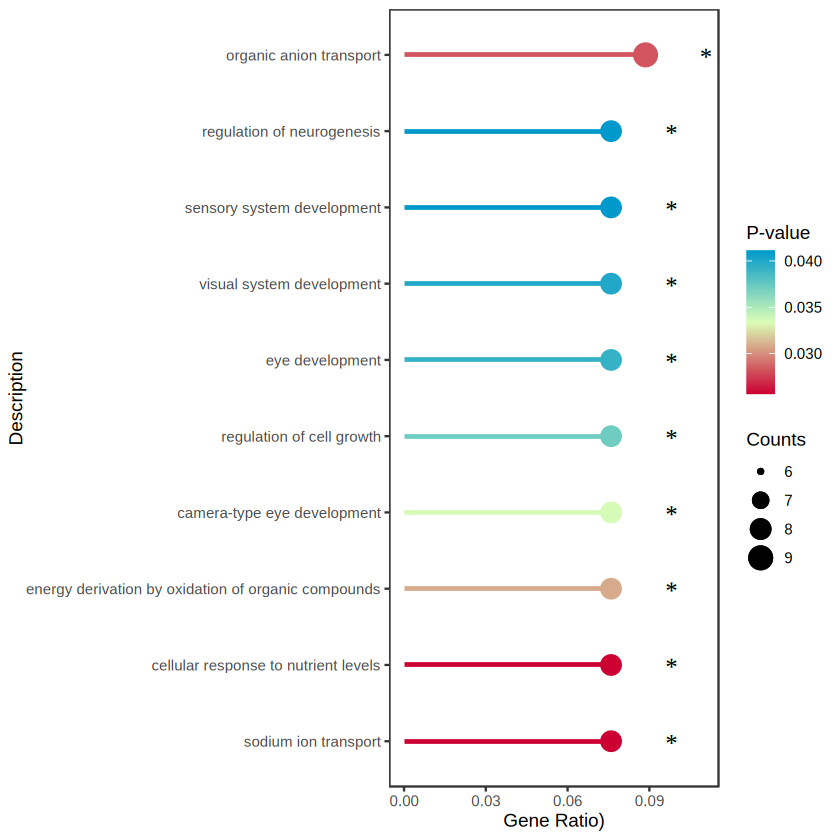

In [421]:
p1 <- ggplot(data = plotdata) +
  geom_segment(aes(x = 0, xend = geneRatio, y = Description, yend = Description,color=get("p.adjust")), linewidth = 1, show.legend = F) + 
  geom_point(aes(x = geneRatio, y = Description, color=get("p.adjust"),size = get('Count')+2)) + 
  geom_point(aes(x = geneRatio, y = Description,  color=get("p.adjust"),size = get('Count')),  shape = 21, fill = NA)+theme_bw()+labs(color="p.adjust",size="Counts",x="Gene Ratio)")+#scale_color_gradient2()+
theme(panel.grid.major = element_blank(),
        panel.grid.minor = element_blank())+geom_text(data = plotdata ,
            aes(x = geneRatio + 0.02 , y = Description, label = Signif),
            size = 5,
            vjust = 0.7,#color="#007F73",
            hjust = 0,
            family = "serif", 
            show.legend = F
  )+scale_color_gradientn(colours = colorRampPalette(rev(c('#5749a0', '#0f7ab0', '#00bbb1',
                                    '#bef0b0', '#fdf4af', '#f9b64b',
                                    '#ec840e', '#ca443d', '#a51a49')))(100))+
xlim(0, 0.11)
p1
p2 <- ggplot(data = plotdata) +
  geom_segment(aes(x = 0, xend = geneRatio, y = Description, yend = Description,color=get("p.adjust")), linewidth = 1, show.legend = F) + 
  geom_point(aes(x = geneRatio, y = Description, color=get("p.adjust"),size = get('Count')+2)) + 
  geom_point(aes(x = geneRatio, y = Description,  color=get("p.adjust"),size = get('Count')),  shape = 21, fill = NA)+theme_bw()+labs(color="p.adjust",size="Counts",x="Gene Ratio)")+#scale_color_gradient2()+
theme(panel.grid.major = element_blank(),
        panel.grid.minor = element_blank())+geom_text(data = plotdata ,
            aes(x = geneRatio + 0.02 , y = Description, label = Signif),
            size = 5,
            vjust = 0.7,#color="#007F73",
            hjust = 0,
            family = "serif", 
            show.legend = F
  )+scale_color_gradientn(colours = colorRampPalette(rev(c("#0099CC", "#DCFFB7", "#CC0033")))(100))+
xlim(0, 0.11)
p2
pdf("down.pdf",width = 5,height = 6)
print(p1)
print(p1+theme(axis.text.y = element_blank()))
print(p2)
print(p2+theme(axis.text.y = element_blank()))
dev.off()

In [422]:
unique(plotdata$Description)

[1] sodium ion transport                               
 [2] cellular response to nutrient levels               
 [3] energy derivation by oxidation of organic compounds
 [4] camera-type eye development                        
 [5] regulation of cell growth                          
 [6] eye development                                    
 [7] visual system development                          
 [8] sensory system development                         
 [9] regulation of neurogenesis                         
[10] organic anion transport                            
10 Levels: sodium ion transport ... organic anion transport

In [423]:
lev1 <- c('organic anion transport','regulation of neurogenesis','sensory system development',
          'visual system development','eye development','regulation of cell growth','camera-type eye development',
          'energy derivation by oxidation of organic compounds','cellular response to nutrient levels','sodium ion transport')

In [424]:
plotdata <- up

In [428]:
plotdata$Signif <- " "
plotdata[which(plotdata$`p.adjust`>=0.01&plotdata$`p.adjust`<0.05),]$Signif <- "*"
plotdata[which(plotdata$`p.adjust`>=0.001&plotdata$`p.adjust`<0.01),]$Signif <- "**"
plotdata[which(plotdata$`p.adjust`<0.001),]$Signif <- "***"

plotdata$geneRatio <- plotdata$Count/303

In [429]:
unique(plotdata$Signif)

[1] "***" "**"  "*"

In [431]:
plotdata <- plotdata %>%
  arrange(p.adjust) %>%
  head(10)

In [432]:
plotdata

,ID,Description,GeneRatio,BgRatio,RichFactor,FoldEnrichment,zScore,pvalue,p.adjust,qvalue,geneID,Count,Signif,geneRatio
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>,<dbl>
GO:0050900,GO:0050900,leukocyte migration,54/303,409/28928,0.13202934,12.605098,24.31888,4.847644e-43,1.891551e-39,1.033314e-39,Spp1/Ccl6/Lgmn/Fcer1g/Itgam/Grem1/Msn/Mmp14/Coro1a/Fcgr3/Pf4/Il1b/Aif1/C3ar1/Pla2g7/Serpine1/Thbs1/Csf1r/Ccl9/Lgals3/Ccl2/Vcam1/S100a9/Sirpa/Ccr2/Ecm1/S100a8/Itgb2/P2rx4/Nckap1l/Prex1/Ptafr/Csf3r/Wnt5a/Adam17/Cmklr1/Ccl8/Trem2/Syk/Gpsm3/Vav1/Cxcl16/Myd88/Tlr2/Myo1f/Ccl7/Cxcl10/Dock8/Ccr1/Spi1/Ccl5/Itga4/Mmp9/Fpr2,54,***,0.1782178
GO:0097529,GO:0097529,myeloid leukocyte migration,43/303,256/28928,0.16796875,16.036304,24.86179,7.051207e-39,1.375690e-35,7.515102e-36,Spp1/Ccl6/Lgmn/Fcer1g/Itgam/Grem1/Mmp14/Fcgr3/Pf4/Il1b/Aif1/C3ar1/Pla2g7/Serpine1/Thbs1/Csf1r/Ccl9/Lgals3/Ccl2/S100a9/Sirpa/Ccr2/S100a8/Itgb2/P2rx4/Nckap1l/Prex1/Csf3r/Cmklr1/Ccl8/Trem2/Syk/Vav1/Myd88/Tlr2/Myo1f/Ccl7/Cxcl10/Ccr1/Spi1/Ccl5/Mmp9/Fpr2,43,***,0.1419142
GO:0060326,GO:0060326,cell chemotaxis,46/303,337/28928,0.13649852,13.031779,22.85759,2.507673e-37,3.261646e-34,1.781768e-34,Spp1/Saa3/Ccl6/Lgmn/Fcer1g/Itgam/Grem1/Coro1a/Fcgr3/Pf4/Il1b/Aif1/C3ar1/Pla2g7/Serpine1/Thbs1/Csf1r/Ccl9/Lgals3/Ccl2/Vcam1/Ccr5/S100a9/Ccr2/S100a8/Itgb2/P2rx4/Nckap1l/Arrb2/Prex1/Csf3r/Wnt5a/Adam17/Cmklr1/Ccl8/Syk/Gpsm3/Vav1/Cxcl16/Ccl7/Cxcl10/Ccr1/Spi1/Ccl5/Mmp9/Fpr2,46,***,0.1518152
GO:0030595,GO:0030595,leukocyte chemotaxis,41/303,243/28928,0.16872428,16.108436,24.33299,3.584379e-37,3.496562e-34,1.910097e-34,Spp1/Ccl6/Lgmn/Fcer1g/Itgam/Grem1/Coro1a/Fcgr3/Pf4/Il1b/Aif1/C3ar1/Pla2g7/Serpine1/Thbs1/Csf1r/Ccl9/Lgals3/Ccl2/S100a9/Ccr2/S100a8/Itgb2/Nckap1l/Prex1/Csf3r/Wnt5a/Adam17/Cmklr1/Ccl8/Syk/Gpsm3/Vav1/Cxcl16/Ccl7/Cxcl10/Ccr1/Spi1/Ccl5/Mmp9/Fpr2,41,***,0.1353135
GO:0006935,GO:0006935,chemotaxis,52/303,481/28928,0.10810811,10.321292,21.20951,5.807795e-37,4.532403e-34,2.475955e-34,Spp1/Saa3/Ccl6/Fn1/Lgmn/Fcer1g/Itgam/Grem1/Coro1a/Fcgr3/Pf4/Il1b/Aif1/C3ar1/Pla2g7/Serpine1/Thbs1/Csf1r/Ccl9/Lgals3/Ccl2/Vcam1/Ccr5/S100a9/Ccr2/S100a8/Itgb2/S100a4/P2rx4/Nckap1l/Arrb2/Prex1/Ptafr/Csf3r/Wnt5a/Dock2/Adam17/Cmklr1/Ccl8/Trem2/Syk/Gpsm3/Vav1/Cxcl16/Ccl7/Cxcl10/Ccr1/Spi1/Ccl5/Mmp9/Fpr2/Fpr1,52,***,0.1716172
GO:0042330,GO:0042330,taxis,52/303,483/28928,0.10766046,10.278553,21.15686,7.170025e-37,4.662906e-34,2.547246e-34,Spp1/Saa3/Ccl6/Fn1/Lgmn/Fcer1g/Itgam/Grem1/Coro1a/Fcgr3/Pf4/Il1b/Aif1/C3ar1/Pla2g7/Serpine1/Thbs1/Csf1r/Ccl9/Lgals3/Ccl2/Vcam1/Ccr5/S100a9/Ccr2/S100a8/Itgb2/S100a4/P2rx4/Nckap1l/Arrb2/Prex1/Ptafr/Csf3r/Wnt5a/Dock2/Adam17/Cmklr1/Ccl8/Trem2/Syk/Gpsm3/Vav1/Cxcl16/Ccl7/Cxcl10/Ccr1/Spi1/Ccl5/Mmp9/Fpr2/Fpr1,52,***,0.1716172
GO:0006909,GO:0006909,phagocytosis,38/303,241/28928,0.15767635,15.053668,22.54010,2.452042e-33,1.366838e-30,7.466745e-31,C3/Fcer1g/Itgam/Tyrobp/Coro1a/Fcgr3/Myh9/Aif1/Msr1/Ptprc/Thbs1/Cyba/Ccl2/Cfp/Sirpa/Fcgr2b/Fcgr1/Ccr2/Abca1/Itgb2/Nckap1l/Pld4/Pros1/Tgm2/Dock2/Hck/Cd300lf/Ncf2/Trem2/Syk/Fgr/Vav1/Irf8/Myd88/Tlr2/P2ry6/Fpr2/Cdc42se1,38,***,0.1254125
GO:0002697,GO:0002697,regulation of immune effector process,48/303,487/28928,0.09856263,9.409966,19.25691,2.979890e-32,1.453442e-29,7.939839e-30,C3/H2-K1/H2-D1/Fcer1g/Grn/Itgam/Laptm5/Tyrobp/Lgals1/Fcgr3/Pf4/Arg1/Il1b/Ptprc/Lgals3/Ccl2/Cfp/S100a9/Fcgr2b/Fcgr1/Ccr2/Lilrb4a/Itgb2/Ptpn6/Nckap1l/Arrb2/Ptafr/Irf5/Wnt5a/Ncf1/Litaf/Rsad2/H2-Q7/Cd84/Pnp/Arid5a/Stx7/Trem2/Syk/Vsir/Sash3/Fgr/Vav1/Hmox1/Myd88/Tlr2/Spi1/Il13ra1,48,***,0.1584158
GO:0002687,GO:0002687,positive regulation of leukocyte migration,32/303,180/28928,0.17777778,16.972791,22.11635,6.329744e-30,2.744295e-27,1.499150e-27,Lgmn/Mmp14/Coro1a/Il1b/Aif1/C3ar1/Pla2g7/Serpine1/Thbs1/Csf1r/Lgals3/Ccl2/Ccr2/P2rx4/Nckap1l/Ptafr/Wnt5a/Adam17/Cmklr1/Trem2/Gpsm3/Tlr2/Myo1f/Ccl7/Cxcl10/Dock8/Ccr1/Spi1/Ccl5/Itga4/Mmp9/Fpr2,32,***,0.1056106


In [433]:
plotdata <- plotdata[order(plotdata$geneRatio),]
lev <- plotdata$Description

In [434]:
plotdata$Description <- factor(plotdata$Description,levels = (lev))

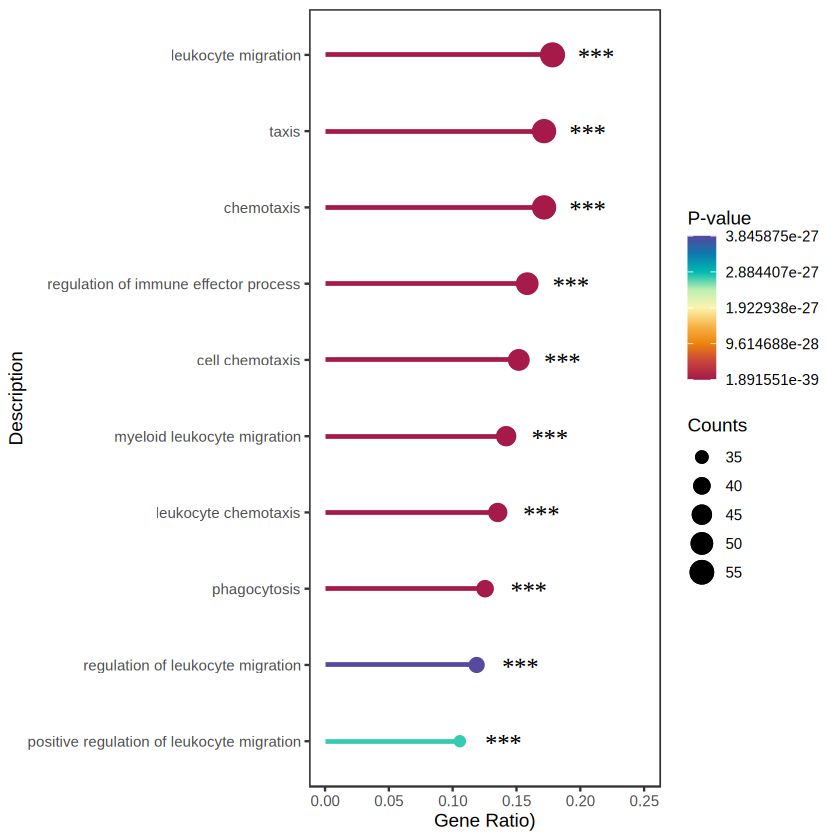

pdf 
  2

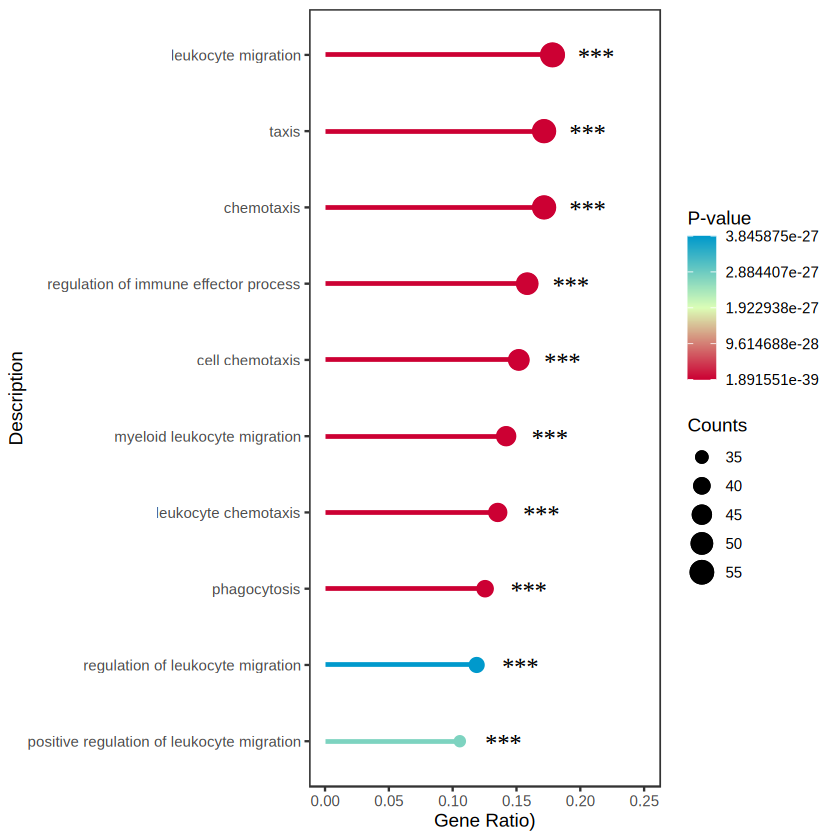

In [437]:
p1 <- ggplot(data = plotdata) +
  geom_segment(aes(x = 0, xend = geneRatio, y = Description, yend = Description,color=get("p.adjust")), linewidth = 1, show.legend = F) + # 绘制棒棒糖的棒
  geom_point(aes(x = geneRatio, y = Description, color=get("p.adjust"),size = get('Count')+2)) + # 绘制棒棒糖的糖中心圆
  geom_point(aes(x = geneRatio, y = Description,  color=get("p.adjust"),size = get('Count')),  shape = 21, fill = NA)+theme_bw()+labs(color="P-value",size="Counts",x="Gene Ratio)")+#scale_color_gradient2()+
theme(panel.grid.major = element_blank(),
        panel.grid.minor = element_blank())+geom_text(data = plotdata ,
            aes(x = geneRatio + 0.02 , y = Description, label = Signif),
            size = 5,
            vjust = 0.7,#color="#007F73",
            hjust = 0,
            family = "serif", 
            show.legend = F
  )+scale_color_gradientn(colours = colorRampPalette(rev(c('#5749a0', '#0f7ab0', '#00bbb1',
                                    '#bef0b0', '#fdf4af', '#f9b64b',
                                    '#ec840e', '#ca443d', '#a51a49')))(100))+
xlim(0, 0.25)
p1
p2 <- ggplot(data = plotdata) +
  geom_segment(aes(x = 0, xend = geneRatio, y = Description, yend = Description,color=get("p.adjust")), linewidth = 1, show.legend = F) + # 绘制棒棒糖的棒
  geom_point(aes(x = geneRatio, y = Description, color=get("p.adjust"),size = get('Count')+2)) + # 绘制棒棒糖的糖中心圆
  geom_point(aes(x = geneRatio, y = Description,  color=get("p.adjust"),size = get('Count')),  shape = 21, fill = NA)+theme_bw()+labs(color="P-value",size="Counts",x="Gene Ratio)")+#scale_color_gradient2()+
theme(panel.grid.major = element_blank(),
        panel.grid.minor = element_blank())+geom_text(data = plotdata ,
            aes(x = geneRatio + 0.02 , y = Description, label = Signif),
            size = 5,
            vjust = 0.7,#color="#007F73",
            hjust = 0,
            family = "serif", 
            show.legend = F
  )+scale_color_gradientn(colours = colorRampPalette(rev(c("#0099CC", "#DCFFB7", "#CC0033")))(100))+
xlim(0, 0.25)
p2
pdf("up.pdf",width = 5,height = 6)
print(p1)
print(p1+theme(axis.text.y = element_blank()))
print(p2)
print(p2+theme(axis.text.y = element_blank()))
dev.off()